
=== STAGE 3: OVERALL ROBUSTNESS SCORECARD ===
                           Welfare  Turnaways  Transferred  Service_Level  \
Policy                                                                      
Safety Buffer            104850.51       4.24         7.63           0.98   
MILP Optimal             104623.96       4.35         7.65           0.98   
Proportional Allocation  102560.74       5.23         7.90           0.98   

                         Utilization  Staffing_Cost  Total_Staff  
Policy                                                            
Safety Buffer                   0.96        4827.51         19.0  
MILP Optimal                    0.96        4825.02         19.0  
Proportional Allocation         0.97        4827.26         19.0  

=== EXTREME WEATHER ONLY (-15°C) SCORECARD ===
                           Welfare  Turnaways  Transferred  Service_Level  \
Policy                                                                      
Safety Buffer            11621

C:\Users\Fangyuan Bao\AppData\Local\Temp\ipykernel_4928\698988309.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(boxplot_data, labels=list(POLICIES.keys()))


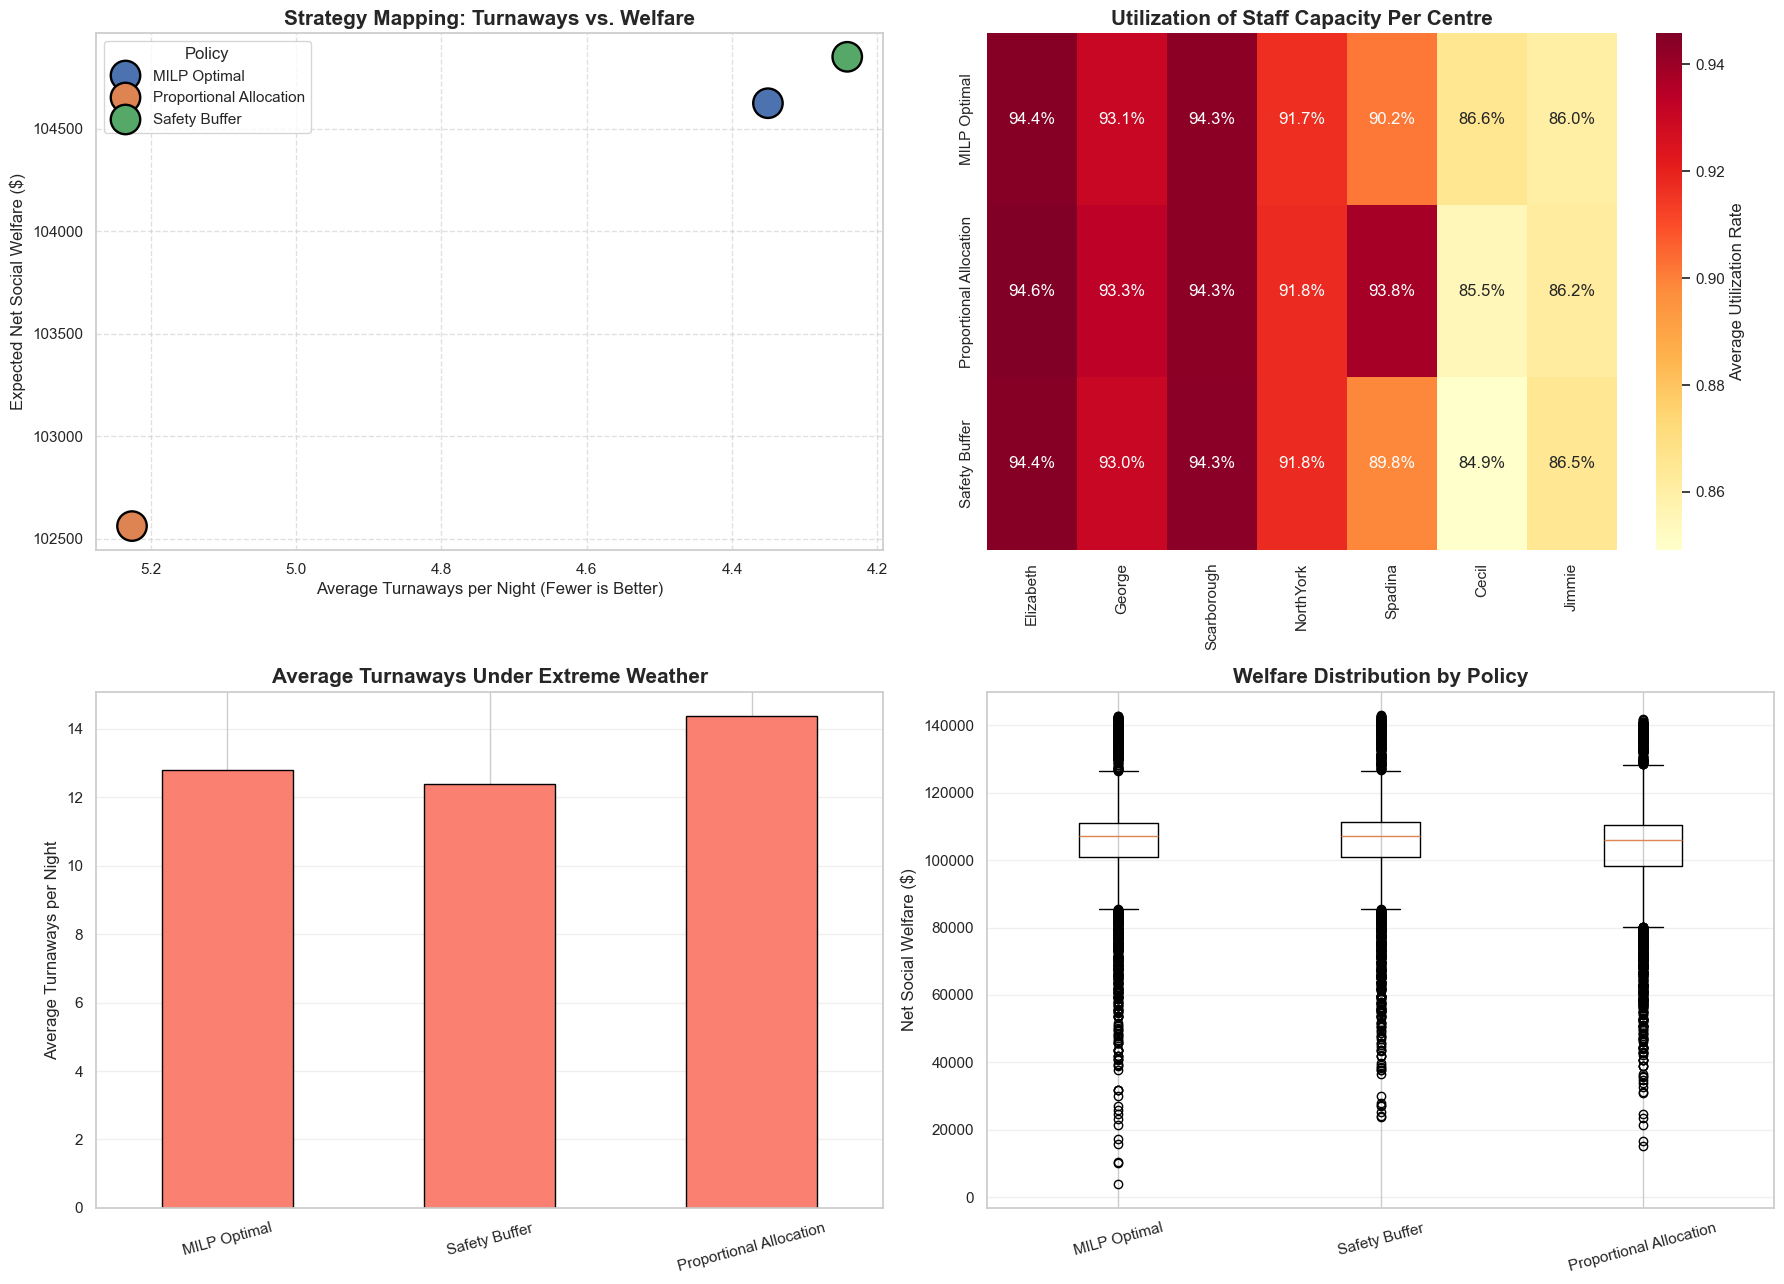

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

ITERATIONS = 5000
HOURS_OPEN = 12
EXTREME_PROB = 0.12
STAFF_RATIO = 20  # 1 staff can support 20 clients/beds

BASE_RATES = {
    "Elizabeth": 6.08,
    "George": 2.50,
    "Scarborough": 5.52,
    "NorthYork": 3.63,
    "Spadina": 1.76,
    "Cecil": 2.21,
    "Jimmie": 2.20,
}

CAPS = {
    "Elizabeth": 75,
    "George": 30,
    "Scarborough": 68,
    "NorthYork": 46,
    "Spadina": 22,
    "Cecil": 30,
    "Jimmie": 30,
}

EXTREME_ONLY_CENTERS = ["Cecil", "Jimmie"]

# Welfare / cost assumptions
BENEFIT_PER_ADMIT = 500
PENALTY_PER_TURNAWAY = 2000
STAFF_COST_PER_UNIT = 312
TRANSFER_COST = 147

TOTAL_STAFF_BUDGET = 19

MILP_STAFF = {
    "Elizabeth": 4,
    "George": 2,
    "Scarborough": 4,
    "NorthYork": 3,
    "Spadina": 2,
    "Cecil": 2,
    "Jimmie": 2,
}


# Safety buffer benchmark
SAFETY_BUFFER = {}
for center, rate in BASE_RATES.items():
    peak_demand_est = (rate * HOURS_OPEN * 1.4) + 5
    safe_peak = min(CAPS[center], peak_demand_est)
    SAFETY_BUFFER[center] = int(np.ceil(safe_peak / STAFF_RATIO))

# Proportional benchmarks
total_rate = sum(BASE_RATES.values())
PROPORTIONAL_STAFF = {
    c: max(1, round((rate / total_rate) * TOTAL_STAFF_BUDGET))
    for c, rate in BASE_RATES.items()
}
# Fix rounding gap so total staff matches budget
PROPORTIONAL_STAFF["Elizabeth"] += TOTAL_STAFF_BUDGET - sum(PROPORTIONAL_STAFF.values())

POLICIES = {
    "MILP Optimal": MILP_STAFF,
    "Safety Buffer": SAFETY_BUFFER,
    "Proportional Allocation": PROPORTIONAL_STAFF,
}


def simulate_one_night(policy_name: str, staff_config: dict) -> dict:
    is_extreme = np.random.random() < EXTREME_PROB
    scenario = "Extreme (-15°C)" if is_extreme else "Moderate (-5°C)"

    total_demand = 0
    total_initial_served = 0
    total_overflow = 0
    total_vacancy = 0
    total_effective_capacity = 0
    nightly_staff_cost = 0
    center_utils = {}

    for center, base_rate in BASE_RATES.items():
        # Extreme-only centers closed in moderate weather
        if (not is_extreme) and (center in EXTREME_ONLY_CENTERS):
            center_utils[center] = np.nan
            continue

        # Weather multiplier
        if is_extreme and center in EXTREME_ONLY_CENTERS:
            weather_mult = 1.0
        elif is_extreme:
            weather_mult = 1.1
        else:
            weather_mult = 1.0

        # Stochastic demand
        lam = base_rate * HOURS_OPEN * weather_mult
        demand = np.random.poisson(lam)

        # Effective capacity = min(physical capacity, staffing capacity)
        staff_limit = staff_config[center] * STAFF_RATIO
        effective_cap = min(CAPS[center], staff_limit)

        total_demand += demand
        total_effective_capacity += effective_cap
        nightly_staff_cost += staff_config[center] * STAFF_COST_PER_UNIT

        served_here = min(demand, effective_cap)
        center_utils[center] = (served_here / effective_cap) if effective_cap > 0 else 0

        if demand > effective_cap:
            total_overflow += (demand - effective_cap)
            total_initial_served += effective_cap
        else:
            total_vacancy += (effective_cap - demand)
            total_initial_served += demand

    # Transfer protocol
    transferred = min(total_overflow, total_vacancy)
    final_served = total_initial_served + transferred
    final_turnaway = total_overflow - transferred

    # Metrics
    service_level = (final_served / total_demand) if total_demand > 0 else 1.0
    utilization = (final_served / total_effective_capacity) if total_effective_capacity > 0 else 0

    welfare = (
        final_served * BENEFIT_PER_ADMIT
        - final_turnaway * PENALTY_PER_TURNAWAY
        - transferred * TRANSFER_COST
        - nightly_staff_cost
    )

    result = {
        "Policy": policy_name,
        "Scenario": scenario,
        "Demand": total_demand,
        "Served": final_served,
        "Turnaways": final_turnaway,
        "Transferred": transferred,
        "Service_Level": service_level,
        "Utilization": utilization,
        "Welfare": welfare,
        "Staffing_Cost": nightly_staff_cost,
        "Total_Staff": sum(staff_config.values()),
    }

    result.update({f"Util_{c}": v for c, v in center_utils.items()})
    return result



all_results = []
for policy_name, policy_config in POLICIES.items():
    for i in range(ITERATIONS):
        row = simulate_one_night(policy_name, policy_config)
        row["Iteration"] = i + 1
        all_results.append(row)

df_all = pd.DataFrame(all_results)

overall_scorecard = (
    df_all.groupby("Policy")[
        ["Welfare", "Turnaways", "Transferred", "Service_Level", "Utilization", "Staffing_Cost", "Total_Staff"]
    ]
    .mean()
    .round(2)
    .sort_values("Welfare", ascending=False)
)

extreme_scorecard = (
    df_all[df_all["Scenario"] == "Extreme (-15°C)"]
    .groupby("Policy")[
        ["Welfare", "Turnaways", "Transferred", "Service_Level", "Utilization", "Staffing_Cost", "Total_Staff"]
    ]
    .mean()
    .round(2)
    .sort_values("Welfare", ascending=False)
)

var_scorecard = (
    df_all.groupby("Policy")["Welfare"]
    .describe(percentiles=[0.05, 0.50, 0.95])[["mean", "5%", "50%", "95%"]]
    .round(0)
    .sort_values("5%", ascending=False)
)

print("\n=== STAGE 3: OVERALL ROBUSTNESS SCORECARD ===")
print(overall_scorecard)

print("\n=== EXTREME WEATHER ONLY (-15°C) SCORECARD ===")
print(extreme_scorecard)

print("\n=== VALUE AT RISK (5% NIGHTMARE SCENARIO WELFARE) ===")
print(var_scorecard)


fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# --- Plot 1: Strategy mapping ---
scatter_df = (
    df_all.groupby("Policy")[["Turnaways", "Welfare"]]
    .mean()
    .reset_index()
)

sns.scatterplot(
    data=scatter_df,
    x="Turnaways",
    y="Welfare",
    hue="Policy",
    s=450,
    ax=axes[0, 0],
    palette="deep",
    edgecolor="black",
)
axes[0, 0].invert_xaxis()
axes[0, 0].set_title("Strategy Mapping: Turnaways vs. Welfare", fontsize=15, fontweight="bold")
axes[0, 0].set_xlabel("Average Turnaways per Night (Fewer is Better)")
axes[0, 0].set_ylabel("Expected Net Social Welfare ($)")
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# --- Plot 2: Heatmap of center utilization ---
util_cols = [c for c in df_all.columns if c.startswith("Util_")]
heatmap_df = df_all.groupby("Policy")[util_cols].mean()
heatmap_df.columns = [c.replace("Util_", "") for c in heatmap_df.columns]

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlOrRd",
    fmt=".1%",
    cbar_kws={"label": "Average Utilization Rate"},
    ax=axes[0, 1],
)
axes[0, 1].set_title("Utilization of Staff Capacity Per Centre", fontsize=15, fontweight="bold")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")

# --- Plot 3: Extreme-weather turnaways ---
extreme_turnaways = (
    df_all[df_all["Scenario"] == "Extreme (-15°C)"]
    .groupby("Policy")["Turnaways"]
    .mean()
    .reindex(POLICIES.keys())
)

extreme_turnaways.plot(kind="bar", ax=axes[1, 0], color="salmon", edgecolor="black")
axes[1, 0].set_title("Average Turnaways Under Extreme Weather", fontsize=15, fontweight="bold")
axes[1, 0].set_ylabel("Average Turnaways per Night")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=15)
axes[1, 0].grid(axis="y", alpha=0.3)

# --- Plot 4: Welfare boxplot ---
boxplot_data = [df_all[df_all["Policy"] == p]["Welfare"] for p in POLICIES.keys()]
axes[1, 1].boxplot(boxplot_data, labels=list(POLICIES.keys()))
axes[1, 1].set_title("Welfare Distribution by Policy", fontsize=15, fontweight="bold")
axes[1, 1].set_ylabel("Net Social Welfare ($)")
axes[1, 1].tick_params(axis="x", rotation=15)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()